# Analyse de l'induction : $B=f(I)$

Notebook pour la partie **4.2.1 / 4.2.2** du labo (mesure de l'induction dans l'entrefer).

Données utilisées :
- Valeurs du screenshot fourni (x = 2 mm et x = 3 mm)
- Consigne du PDF: courant de 0 à 0.6 A par pas de 0.1 A

> Remarque: la valeur mesurée pour **x = 2 mm à I = 0.6 A** n'apparaît pas dans le screenshot (point manquant).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

In [2]:
# Données expérimentales (B en mT)
I_2mm = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
B_2mm = np.array([10.35, 19.14, 27.79, 36.7, 45.6])

I_3mm = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
B_3mm = np.array([6.61, 11.8, 17.3, 22.8, 28.1, 33.7])

print('x = 2 mm ->', len(I_2mm), 'points')
print('x = 3 mm ->', len(I_3mm), 'points')

x = 2 mm -> 5 points
x = 3 mm -> 6 points


In [3]:
def fit_line(I, B):
    # Ajustement affine: B = a*I + b
    a, b = np.polyfit(I, B, 1)
    B_hat = a * I + b
    ss_res = np.sum((B - B_hat) ** 2)
    ss_tot = np.sum((B - np.mean(B)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return a, b, r2

def fit_through_origin(I, B):
    # Ajustement contraint à l'origine: B = k*I
    k = np.dot(I, B) / np.dot(I, I)
    B_hat = k * I
    ss_res = np.sum((B - B_hat) ** 2)
    ss_tot = np.sum((B - np.mean(B)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return k, r2

a2, b2, r2_2 = fit_line(I_2mm, B_2mm)
k2, r2_2_0 = fit_through_origin(I_2mm, B_2mm)
a3, b3, r2_3 = fit_line(I_3mm, B_3mm)
k3, r2_3_0 = fit_through_origin(I_3mm, B_3mm)

print('=== Ajustement affine B = aI + b ===')
print(f'x=2 mm : a={a2:.3f} mT/A, b={b2:.3f} mT, R^2={r2_2:.5f}')
print(f'x=3 mm : a={a3:.3f} mT/A, b={b3:.3f} mT, R^2={r2_3:.5f}')

print('\n=== Ajustement contraint B = kI ===')
print(f'x=2 mm : k={k2:.3f} mT/A, R^2={r2_2_0:.5f}')
print(f'x=3 mm : k={k3:.3f} mT/A, R^2={r2_3_0:.5f}')

=== Ajustement affine B = aI + b ===
x=2 mm : a=88.060 mT/A, b=1.498 mT, R^2=0.99997
x=3 mm : a=54.243 mT/A, b=1.067 mT, R^2=0.99991

=== Ajustement contraint B = kI ===
x=2 mm : k=92.145 mT/A, R^2=0.99734
x=3 mm : k=56.704 mT/A, R^2=0.99736


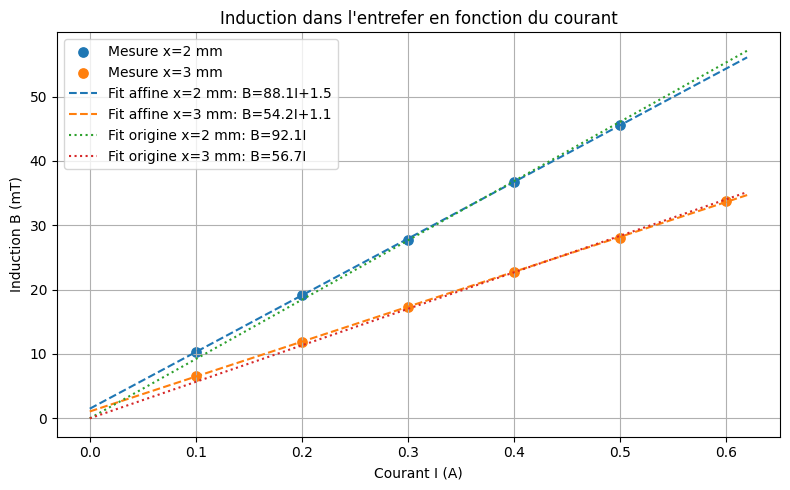

In [4]:
I_plot = np.linspace(0, 0.62, 100)

plt.figure()
plt.scatter(I_2mm, B_2mm, label='Mesure x=2 mm', s=45)
plt.scatter(I_3mm, B_3mm, label='Mesure x=3 mm', s=45)

plt.plot(I_plot, a2*I_plot + b2, '--', label=f'Fit affine x=2 mm: B={a2:.1f}I+{b2:.1f}')
plt.plot(I_plot, a3*I_plot + b3, '--', label=f'Fit affine x=3 mm: B={a3:.1f}I+{b3:.1f}')
plt.plot(I_plot, k2*I_plot, ':', label=f'Fit origine x=2 mm: B={k2:.1f}I')
plt.plot(I_plot, k3*I_plot, ':', label=f'Fit origine x=3 mm: B={k3:.1f}I')

plt.xlabel('Courant I (A)')
plt.ylabel('Induction B (mT)')
plt.title("Induction dans l'entrefer en fonction du courant")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Comparaison de l'effet de l'entrefer
# Théorie simplifiée (fer très perméable): B ~ 1/x à I donné
# donc B(2 mm)/B(3 mm) attendu ~ 3/2 = 1.5

I_common = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
B2_common = B_2mm
B3_common = B_3mm[:5]
ratio = B2_common / B3_common

print('Ratios B(2 mm)/B(3 mm) pour I=0.1..0.5 A:')
print(np.round(ratio, 3))
print(f'Ratio moyen = {np.mean(ratio):.3f}')
print('Ratio théorique simplifié ~ 1.500')

# Estimation du point manquant x=2 mm à I=0.6 A (depuis fit affine)
B2_06_est = a2*0.6 + b2
print(f'\nEstimation B(2 mm, 0.6 A) ~ {B2_06_est:.2f} mT (à vérifier par mesure)')

Ratios B(2 mm)/B(3 mm) pour I=0.1..0.5 A:
[1.566 1.622 1.606 1.61  1.623]
Ratio moyen = 1.605
Ratio théorique simplifié ~ 1.500

Estimation B(2 mm, 0.6 A) ~ 54.33 mT (à vérifier par mesure)


## Commentaire (4.2.2)

1. Les deux courbes $B=f(I)$ sont quasi linéaires sur la plage mesurée (0.1 à 0.6 A), ce qui indique un fonctionnement sans saturation marquée dans cet intervalle.
2. Pour un même courant, l'induction est plus grande pour **x = 2 mm** que pour **x = 3 mm**, conforme à la théorie du circuit magnétique (reluctance d'entrefer plus faible quand $x$ diminue).
3. Le rapport moyen mesuré $B_{2mm}/B_{3mm}$ est proche de la tendance attendue ($\approx 1/x$).
4. Le décalage (interception non nulle) peut venir de l'offset de sonde, de l'alignement dans l'entrefer, de l'hypothèse de champ uniforme, et des dispersions de mesure.

Si tu veux, je peux aussi ajouter la partie théorique symbolique (avec $\mu_r=\infty$ et $\mu_r=400$) sur la même figure pour comparer mesure vs modèle.

## Diagramme de Bode du dernier circuit (intégrateur)

Montage de l'annexe 4.4 avec: $R10=100\,k\Omega$, $R9=10\,k\Omega$, $R11=10\,k\Omega$, $C=1\,\mu F$.


f_c    = 1.592 Hz  (pôle, gain -3 dB par rapport au plateau BF)
f_0dB  = 15.915 Hz  (croisement 0 dB)
Phase à très basse fréq : -183.6°  (attendu ≈ -180°)
Phase à très haute fréq : -270.0°  (attendu ≈ -270°)
Phase à 35 Hz           : -267.4°


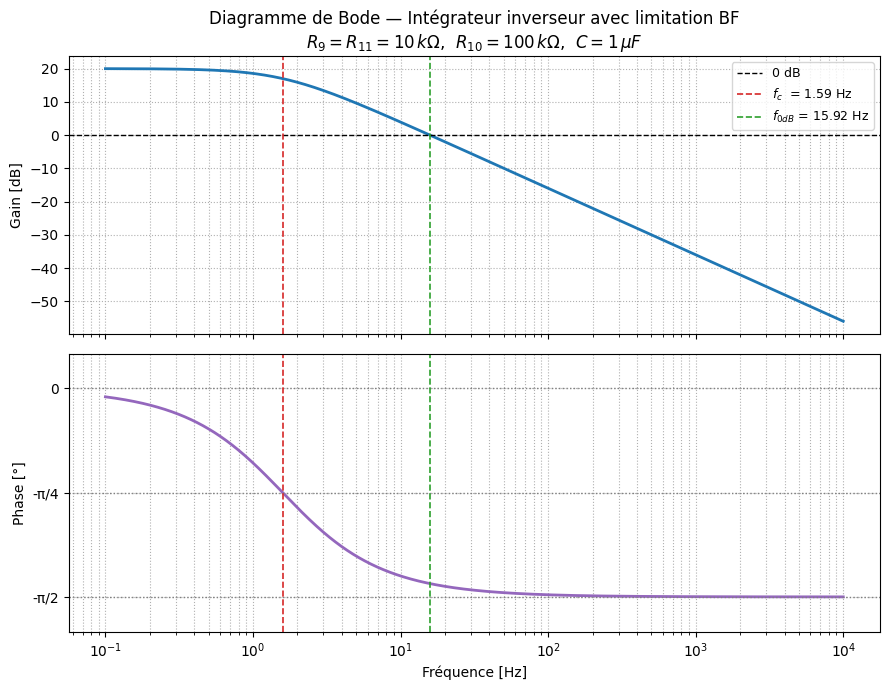

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres du montage intégrateur (annexe 4.4)
# Montage inverseur : H(jw) = -(R10/R9) / (1 + jw*R10*C)
R10 = 100e3   # 100 kΩ
R9  = 10e3    # 10 kΩ
R11 = 10e3    # 10 kΩ (compensation courant de biais)
C   = 1e-6    # 1 µF

# Fréquences
f = np.logspace(-1, 4, 2000)   # 0.1 Hz à 10 kHz
w = 2 * np.pi * f
s = 1j * w

# Fonction de transfert complète (signe − inclus)
H = -(R10 / R9) / (1 + s * R10 * C)

mag_db    = 20 * np.log10(np.abs(H))

# np.angle renvoie dans (-180°, +180°].
# Pour un amplificateur inverseur, la phase réelle est dans (-270°, -180°).
# Correction : on soustrait 360° pour passer de (90°..180°) → (-270°..-180°).
phase_deg = np.angle(H, deg=True) - 360   # ∈ (-270°, -180°)

# Fréquences caractéristiques
fc   = 1 / (2 * np.pi * R10 * C)          # pôle : 1.59 Hz
f0dB = 1 / (2 * np.pi * R9  * C)          # gain = 0 dB : 15.9 Hz

print(f"f_c    = {fc:.3f} Hz  (pôle, gain -3 dB par rapport au plateau BF)")
print(f"f_0dB  = {f0dB:.3f} Hz  (croisement 0 dB)")
print(f"Phase à très basse fréq : {phase_deg[0]:.1f}°  (attendu ≈ -180°)")
print(f"Phase à très haute fréq : {phase_deg[-1]:.1f}°  (attendu ≈ -270°)")
print(f"Phase à 35 Hz           : {np.interp(35, f, phase_deg):.1f}°")

# --- Tracé ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Gain
ax1.semilogx(f, mag_db, lw=2, color='tab:blue')
ax1.axhline(0, color='k', linestyle='--', lw=1, label='0 dB')
ax1.axvline(fc,   color='tab:red',   linestyle='--', lw=1.2, label=f'$f_c$  = {fc:.2f} Hz')
ax1.axvline(f0dB, color='tab:green', linestyle='--', lw=1.2, label=f'$f_{{0dB}}$ = {f0dB:.2f} Hz')
ax1.set_ylabel('Gain [dB]')
ax1.legend(fontsize=9)
ax1.grid(True, which='both', ls=':')
ax1.set_title('Diagramme de Bode — Intégrateur inverseur avec limitation BF\n'
              r'$R_9=R_{11}=10\,k\Omega$,  $R_{10}=100\,k\Omega$,  $C=1\,\mu F$')

# Phase
ax2.semilogx(f, phase_deg, lw=2, color='tab:purple')
ax2.axhline(-180, color='gray', ls=':', lw=1)
ax2.axhline(-225, color='gray', ls=':', lw=1)
ax2.axhline(-270, color='gray', ls=':', lw=1)
ax2.axvline(fc,   color='tab:red',   linestyle='--', lw=1.2)
ax2.axvline(f0dB, color='tab:green', linestyle='--', lw=1.2)
ax2.set_yticks([-270, -225, -180])
ax2.set_yticklabels(['-π/2', '-π/4', '0'])
ax2.set_ylim(-285, -165)
ax2.set_ylabel('Phase [°]')
ax2.set_xlabel('Fréquence [Hz]')
ax2.grid(True, which='both', ls=':')

fig.tight_layout()
fig.savefig('bode_dernier_circuit.png', dpi=180)
import shutil
shutil.copy('bode_dernier_circuit.png',
            'Mécatro labo1/images/bode_dernier_circuit.png')
plt.show()
